In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Loading datasets
flux_dataset = pd.read_csv("../D2/Astro_Flux_Data.csv")
time_dataset = pd.read_csv("../D2/Astro_Time_Data.csv")

In [3]:
# Removing invalid ids
invalid_ids = flux_dataset.loc[~flux_dataset['id'].isin(time_dataset['id']), 'id']
flux_dataset = flux_dataset.drop(flux_dataset[flux_dataset['id'].isin(invalid_ids)].index)
time_dataset = time_dataset.drop(time_dataset[time_dataset['id'].isin(invalid_ids)].index)

In [4]:
#Removing NaN values

def fill_flux_data_mean(row):
    record_mean = row.dropna().mean()
    return row.fillna(record_mean)

def fill_time(row):
    row = row.copy()
    for i in range(1, len(row) - 1):
        if pd.isna(row[i]):
            row[i] = (row[i - 1] + row[i + 1]) / 2
    return row.fillna(method="ffill").fillna(method="bfill")

flux_dataset.iloc[:, 3:] = flux_dataset.iloc[:, 3:].apply(fill_flux_data_mean, axis=1)
time_dataset.iloc[:, 3:] = time_dataset.iloc[:, 3:].apply(fill_time, axis=1)

C:\Users\HP\AppData\Local\Temp\ipykernel_19012\1290360972.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
5995    1.0
5996    1.0
5997    1.0
5998    1.0
5999    1.0
Name: flux_4609, Length: 6000, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  flux_dataset.iloc[:, 3:] = flux_dataset.iloc[:, 3:].apply(fill_flux_data_mean, axis=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_19012\1290360972.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        1162345.0
1        1292087.0
2        1293031.0
3        1162345.0
4        1164109.0
           ...    
5995    11361283.0
5996    11361646.0
5997    11403339.0
5998    11403389.0
5999    11465651.0
Name: flux_4610, Length: 6000, dtype: float64' has dtype incompatible 

In [5]:
from filters import Kalman

filter_instance = Kalman()
from joblib import Parallel, delayed
def process_row(row):
    return filter_instance.apply_filter(row)

filtered_flux = Parallel(n_jobs=-1)(delayed(process_row)(row) for row in flux_dataset.iloc[:, 3:].values)

flux_dataset.iloc[:, 3:] = np.array(filtered_flux, dtype=np.float64).reshape(flux_dataset.iloc[:, 3:].shape)


In [6]:

# Merging datasets
merged_dataset = pd.DataFrame()
merged_dataset['id'] = flux_dataset.sort_values(by="id")['id']
merged_dataset['class'] = flux_dataset.sort_values(by='id')['class']
flux_dataset = flux_dataset.sort_values(by='id')
time_dataset = time_dataset.sort_values(by='id')

for i in range(3, min(flux_dataset.shape[1], time_dataset.shape[1])):
    merged_dataset[f'observation_{i-3}'] = list(zip(flux_dataset.iloc[:, i], time_dataset.iloc[:, i]))

X = merged_dataset.iloc[:, 2:].to_numpy()
y = merged_dataset.iloc[:, 1].values

num_records, num_features = X.shape
num_observations = num_features
X = X.reshape(num_records, num_observations, 1)

X = np.array([[[list(tup) for tup in cell] for cell in row] for row in X])
X = np.stack((X[..., 0], X[..., 1]), axis=-1)
X = X.reshape((6000, 4608, 2))

C:\Users\HP\AppData\Local\Temp\ipykernel_19012\3224087336.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_dataset[f'observation_{i-3}'] = list(zip(flux_dataset.iloc[:, i], time_dataset.iloc[:, i]))
C:\Users\HP\AppData\Local\Temp\ipykernel_19012\3224087336.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_dataset[f'observation_{i-3}'] = list(zip(flux_dataset.iloc[:, i], time_dataset.iloc[:, i]))
C:\Users\HP\AppData\Local\Temp\ipykernel_19012\3224087336.py:9: PerformanceWarning: DataFrame is highly fragmented. 

In [7]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=200)

In [8]:
flux_scaler = StandardScaler()
time_scaler = StandardScaler()

X_train[:, :, 0] = flux_scaler.fit_transform(X_train[:, :, 0])
X_train[:, :, 1] = time_scaler.fit_transform(X_train[:, :, 1])
X_test[:, :, 0] = flux_scaler.transform(X_test[:, :, 0])
X_test[:, :, 1] = time_scaler.transform(X_test[:, :, 1])

joblib.dump(flux_scaler, "flux_scaler.pkl")
joblib.dump(time_scaler, "time_scaler.pkl")

['time_scaler.pkl']

In [9]:
# PyTorch dataset
class ExoplanetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ExoplanetDataset(X_train, y_train)
test_dataset = ExoplanetDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4) 
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/80], Train Loss: 0.6642, Train Acc: 0.5982, Val Loss: 0.6261, Val Acc: 0.5907
Epoch [2/80], Train Loss: 0.5763, Train Acc: 0.6918, Val Loss: 0.5410, Val Acc: 0.7167
Epoch [3/80], Train Loss: 0.5332, Train Acc: 0.7193, Val Loss: 0.5212, Val Acc: 0.7080
Epoch [4/80], Train Loss: 0.5176, Train Acc: 0.7238, Val Loss: 0.5611, Val Acc: 0.7033
Epoch [5/80], Train Loss: 0.4973, Train Acc: 0.7347, Val Loss: 0.5273, Val Acc: 0.7067
Epoch [6/80], Train Loss: 0.4846, Train Acc: 0.7367, Val Loss: 0.4954, Val Acc: 0.7320
Epoch [7/80], Train Loss: 0.4818, Train Acc: 0.7296, Val Loss: 0.5179, Val Acc: 0.7180
Epoch [8/80], Train Loss: 0.4813, Train Acc: 0.7349, Val Loss: 0.4950, Val Acc: 0.7307
Epoch [9/80], Train Loss: 0.4796, Train Acc: 0.7322, Val Loss: 0.4723, Val Acc: 0.7373
Epoch [10/80], Train Loss: 0.4619, Train Acc: 0.7500, Val Loss: 0.4605, Val Acc: 0.7380
Epoch [11/80], Train Loss: 0.4598, Train Acc: 0.7513, Val Loss: 0.4454, Val Acc: 0.7407
Epoch [12/80], Train Loss: 0.4634, Train 

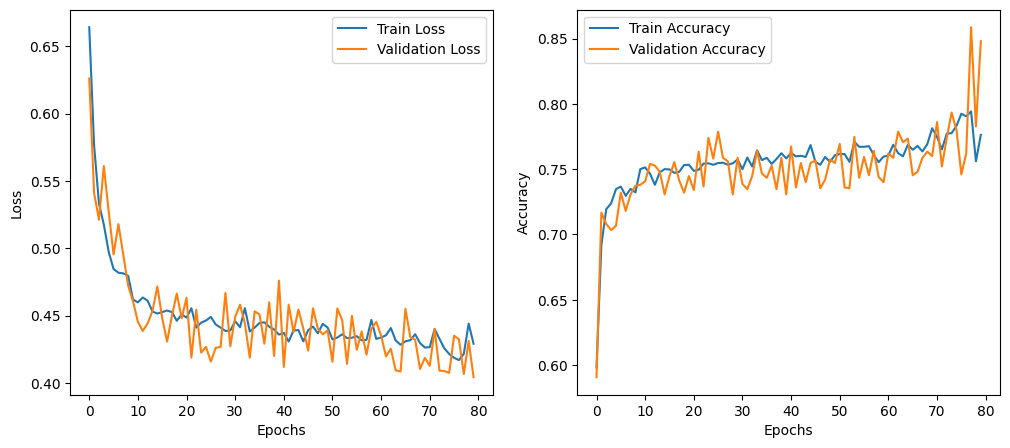

In [11]:
import torch

torch.cuda.empty_cache()

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

import torch
import torch.nn as nn

class Hybrid_LSTM_Transformer(nn.Module):
    def __init__(self):
        super(Hybrid_LSTM_Transformer, self).__init__()

        # 1D CNN Feature Extractor
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # LSTM for Sequential Learning
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, batch_first=True, bidirectional=True)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=512, dropout=0.1)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)

        # Fully Connected Layers (Dense)
        self.fc1 = nn.Linear(128, 32)
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Input shape: (batch_size, seq_len, channels) -> Permute for Conv1D
        x = x.permute(0, 2, 1)  

        # CNN Feature Extraction
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))

        # Restore shape for LSTM
        x = x.permute(0, 2, 1)  

        # LSTM Processing
        x, _ = self.lstm(x)

        # Transformer Processing
        x = self.transformer_encoder(x)

        # Take last timestep output
        x = x[:, -1, :]

        # Fully Connected Layers
        x = self.relu_fc(self.fc1(x))
        x = self.sigmoid(self.fc2(x))

        return x




# Load data
def prepare_data(X_train, y_train, X_test, y_test, batch_size=128):
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)
    
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Training function
def train_model(model, train_loader, test_loader, n_epochs=15, lr=1e-4):
    model.to(device)
    

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3) 
    criterion = nn.BCELoss()
    
    train_losses, val_losses, train_acc, val_acc = [], [], [], []
    
    for epoch in range(n_epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
        train_losses.append(running_loss / len(train_loader))
        train_acc.append(correct / total)
        
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
                
        val_losses.append(val_loss / len(test_loader))
        val_acc.append(correct / total)
        
        print(f"Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")
    
    return train_losses, val_losses, train_acc, val_acc

# Plot results
def plot_results(train_losses, val_losses, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Prediction function
def predict(model, X_test):
    model.to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        predictions = (outputs > 0.5).float().cpu().numpy()
    return predictions

# Initialize and train model
model = Hybrid_LSTM_Transformer()
train_loader, test_loader = prepare_data(X_train, y_train, X_test, y_test, batch_size=64)
history = train_model(model, train_loader, test_loader, n_epochs=80)
plot_results(*history)

# Save model
torch.save(model.state_dict(), "Exoplanet_Flux_Detector_LSTM.pth")
